### E-Commerce US Dataset -- Data Cleaning & EDA

\Importing Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [24]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.titlesize"]=13

\Loading the integrated dataset

In [4]:
integrated_path = r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\raw_integrated"

master = pd.read_csv(os.path.join(integrated_path,"master_orders.csv"))
items_enriched = pd.read_csv(os.path.join(integrated_path,"items_enriched.csv"))

Insights:
 
 -- there is no duplicated record
 
 -- categorical variables has standard values
 
 -- data types for numeric and categorical columns are in correct types 
 
 -- so these steps are skipped for this dataset

\Date Conversion

In [6]:
master_date_cols = ["order_purchase_timestamp","order_approved_at",
             "order_delivered_carrier_date","order_delivered_customer_date",
             "order_estimated_delivery_date"]
for col in master_date_cols:
    master[col]=pd.to_datetime(master[col],errors="coerce")

master[master_date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [7]:
items_enriched["shipping_limit_date"] = pd.to_datetime(items_enriched["shipping_limit_date"],errors="coerce")

\Missing value treatment

In [9]:
master["is_delivered"]=master["order_delivered_customer_date"].notna().astype(int)
master["has_review"]=master["avg_review_score"].notna().astype(int)
master["n_reviews"]=master["n_reviews"].fillna(0).astype(int)

In [10]:
master["is_delivered"].value_counts()

is_delivered
1    9332
0     668
Name: count, dtype: int64

\Dropping Redundant columns

In [11]:
if "price_prod" in items_enriched.columns:
    items = items_enriched.drop(columns=["price_prod"])

In [22]:
\Outlier Detection

In [19]:
# Outlier Detection Fn
def detect_outlier(df,col):
    q1,q3=df[col].quantile(0.25),df[col].quantile(0.75)
    iqr=q3-q1
    lower,upper = q1-1.5*iqr, q3+1.5*iqr
    n=((df[col]<lower)|(df[col]>upper)).sum()
    return round(lower,1),round(upper,1),n,upper

In [20]:
#master 
for col in ["total_payment","total_price","n_items","customer_age"]:
    lower,upper,n,_=detect_outlier(master,col)
    print(f"   {col:16s}: fence[{lower},{upper}], {n} outliers ({n/len(master)*100:.1f}%)")

   total_payment   : fence[-1675.9,3857.7], 225 outliers (2.2%)
   total_price     : fence[-1761.1,3481.0], 221 outliers (2.2%)
   n_items         : fence[-2.0,6.0], 0 outliers (0.0%)
   customer_age    : fence[3.0,67.0], 35 outliers (0.4%)


In [21]:
#items_enriched
for col in ["price","freight_value","product_weight_g"]:
    lower,upper,n,_=detect_outlier(items_enriched,col)
    print(f"   {col:16s}: fence[{lower},{upper}], {n} outliers ({n/len(items_enriched)*100:.1f}%)")

   price           : fence[-947.1,1746.4], 863 outliers (4.0%)
   freight_value   : fence[-78.8,302.3], 0 outliers (0.0%)
   product_weight_g: fence[-3945.0,8135.0], 2297 outliers (10.5%)


\Flagging High Values

In [22]:
_,_,_,pay_upper =detect_outlier(master,"total_payment")
master["is_high_value"]= (master["total_payment"]>pay_upper).astype(int)
master["is_high_value"].value_counts()

is_high_value
0    9775
1     225
Name: count, dtype: int64

\Saving the cleaned dataset

In [23]:
master.to_csv(os.path.join(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\processed", "master_clean.csv"), index=False)
items.to_csv(os.path.join(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\processed", "items_clean.csv"), index=False)

### EDA

\Loading the Cleaned dataset

In [27]:
processed_path=r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\processed"

master=pd.read_csv(os.path.join(processed_path,"master_clean.csv"))
items=pd.read_csv(os.path.join(processed_path,"items_clean.csv")   )               

\Dates conversion

In [30]:
for col in master_date_cols:
    master[col]=pd.to_datetime(master[col],errors="coerce")
items["shipping_limit_date"]=pd.to_datetime(items["shipping_limit_date"],errors="coerce")
    

\Customer Analysis

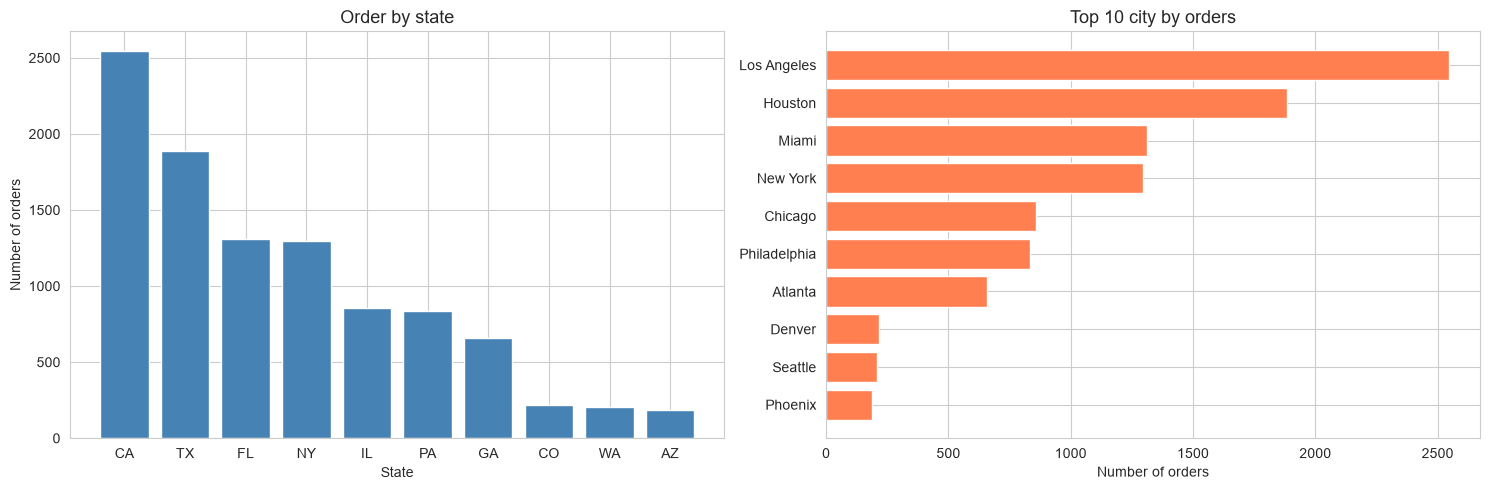

Top 3 states: customer_state
CA    2546
TX    1885
FL    1312
Name: count, dtype: int64


In [36]:
fig ,axes =plt.subplots(1,2,figsize =(15,5))

#order by state
state_count = master["customer_state"].value_counts()
axes[0].bar(state_count.index,state_count.values,color="steelblue")
axes[0].set_title("Order by state")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of orders")

#order by city
city_counts = master["customer_city"].value_counts().head(10)
axes[1].barh(city_counts.index[::-1],city_counts.values[::-1],color = "coral")
axes[1].set_title("Top 10 city by orders")
axes[1].set_xlabel("Number of orders")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\customer_distribution.png",dpi = 100,bbox_inches = "tight")
plt.show()
print("Top 3 states:", state_count.head(3))

\Customer Demographics

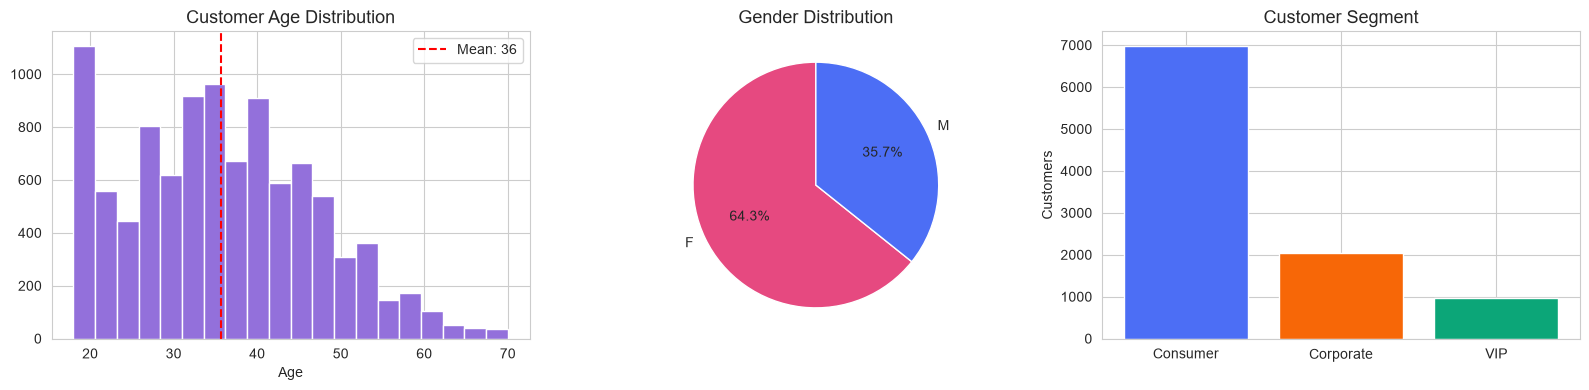

In [43]:
fig, axes = plt.subplots(1,3,figsize=(16,4))

#age distribution
axes[0].hist(master["customer_age"],bins=20,color="mediumpurple", edgecolor="white")
axes[0].axvline(master["customer_age"].mean(), color='red',linestyle ="--",
                label = f"Mean: {master["customer_age"].mean():.0f}")
axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

#gender
gender_counts = master["customer_gender"].value_counts()
axes[1].pie(gender_counts.values,labels =gender_counts.index, autopct ="%1.1f%%",
            colors=["#E64980","#4C6EF5"],startangle=90)
axes[1].set_title("Gender Distribution")

#segment
seg_counts = master["customer_segment"].value_counts()
axes[2].bar(seg_counts.index,seg_counts.values,color=["#4C6EF5","#F76707","#0CA678"])
axes[2].set_title("Customer Segment")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\customer_demograpies.png",dpi =100,bbox_inches ="tight")
plt.show()


\Customer Acquistion Trend

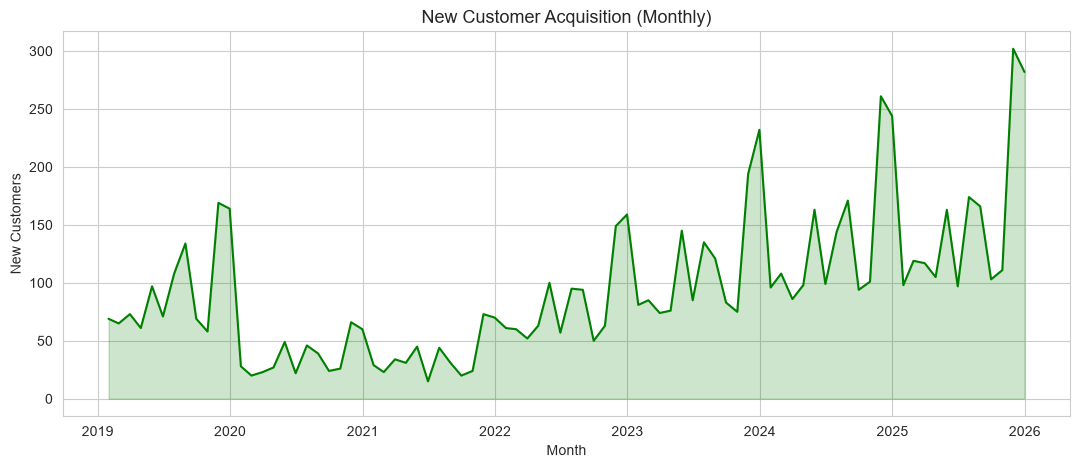

Total unique customers: 7898


In [50]:
master_sorted = master.sort_values("order_purchase_timestamp")
first_orders = master_sorted.drop_duplicates("customer_unique_id", keep="first")

# Monthly new customers
monthly_new = first_orders.set_index("order_purchase_timestamp").resample("ME").size()

plt.figure(figsize=(13, 5))
plt.plot(monthly_new.index, monthly_new.values, color="green", linewidth=1.5)
plt.fill_between(monthly_new.index, monthly_new.values, alpha=0.2, color="green")
plt.title("New Customer Acquisition (Monthly)")
plt.xlabel("Month"); plt.ylabel("New Customers")
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\customer_acquisition.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Total unique customers: {first_orders['customer_unique_id'].nunique()}")

\Order Analysis

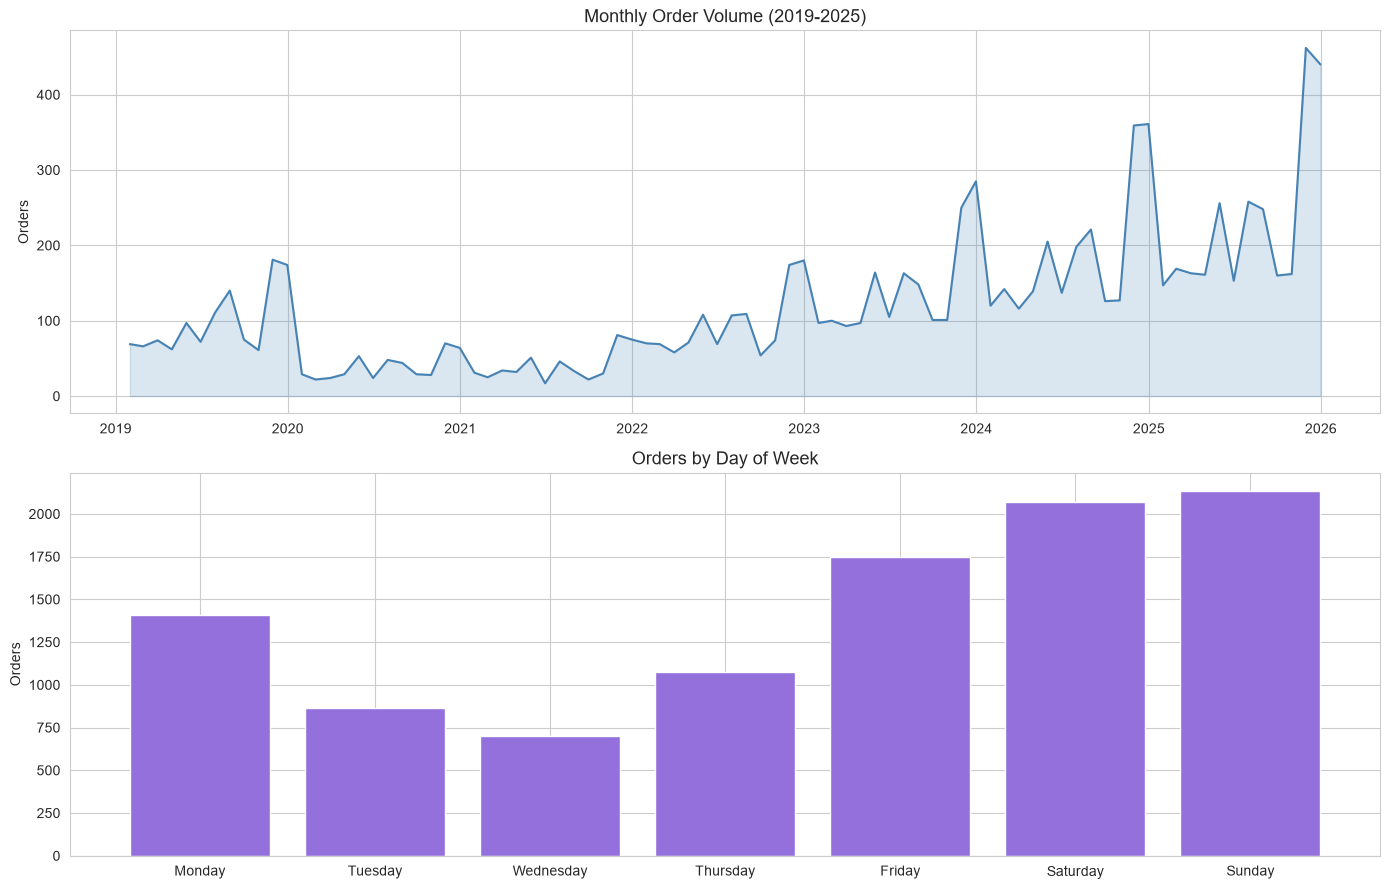

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Monthly order volume
monthly_orders = master.set_index("order_purchase_timestamp").resample("ME").size()
axes[0].plot(monthly_orders.index, monthly_orders.values, color="steelblue", linewidth=1.5)
axes[0].fill_between(monthly_orders.index, monthly_orders.values, alpha=0.2, color="steelblue")
axes[0].set_title("Monthly Order Volume (2019-2025)")
axes[0].set_ylabel("Orders")

# Day of week pattern
master["day_of_week"] = master["order_purchase_timestamp"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = master["day_of_week"].value_counts().reindex(dow_order)
axes[1].bar(dow_counts.index, dow_counts.values, color="mediumpurple")
axes[1].set_title("Orders by Day of Week")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\order_volume.png", dpi=100, bbox_inches="tight")
plt.show()

\Order status + delivery performance

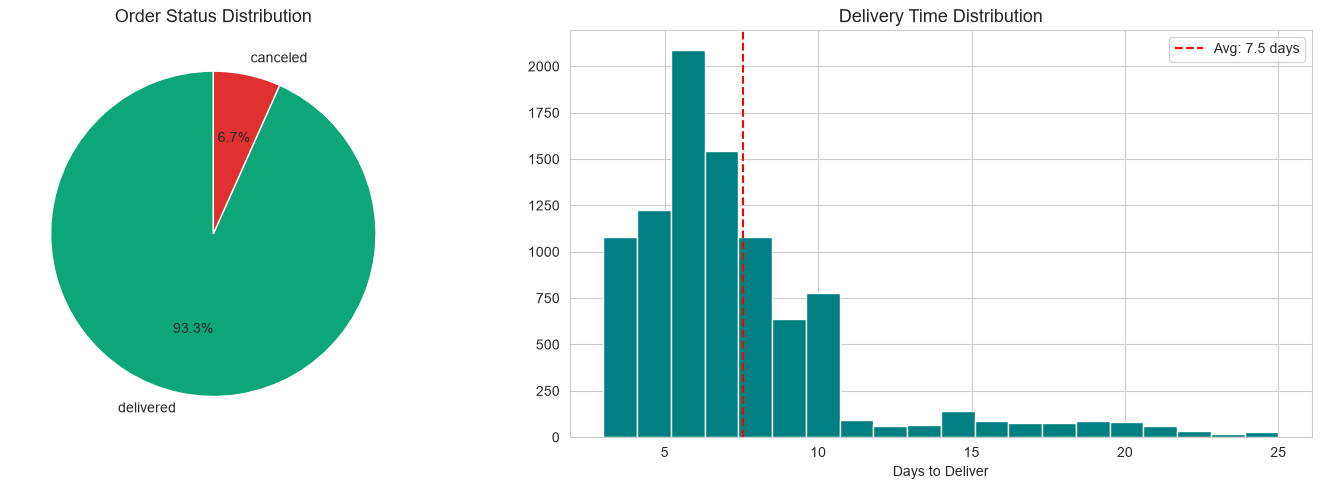

Avg delivery: 7.5 days, Cancel rate: 6.7%


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Order status pie
status_counts = master["order_status"].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%",
            colors=["#0CA678","#E03131"], startangle=90)
axes[0].set_title("Order Status Distribution")

# Delivery time distribution
delivered = master[master["is_delivered"]==1].copy()
delivered["delivery_days"] = (delivered["order_delivered_customer_date"] -
                               delivered["order_purchase_timestamp"]).dt.days
axes[1].hist(delivered["delivery_days"], bins=20, color="teal", edgecolor="white")
axes[1].axvline(delivered["delivery_days"].mean(), color="red", linestyle="--",
                label=f"Avg: {delivered['delivery_days'].mean():.1f} days")
axes[1].set_title("Delivery Time Distribution")
axes[1].set_xlabel("Days to Deliver"); axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\order_delivery.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Avg delivery: {delivered['delivery_days'].mean():.1f} days, "
      f"Cancel rate: {(master['order_status']=='canceled').mean()*100:.1f}%")

\Product Analysis

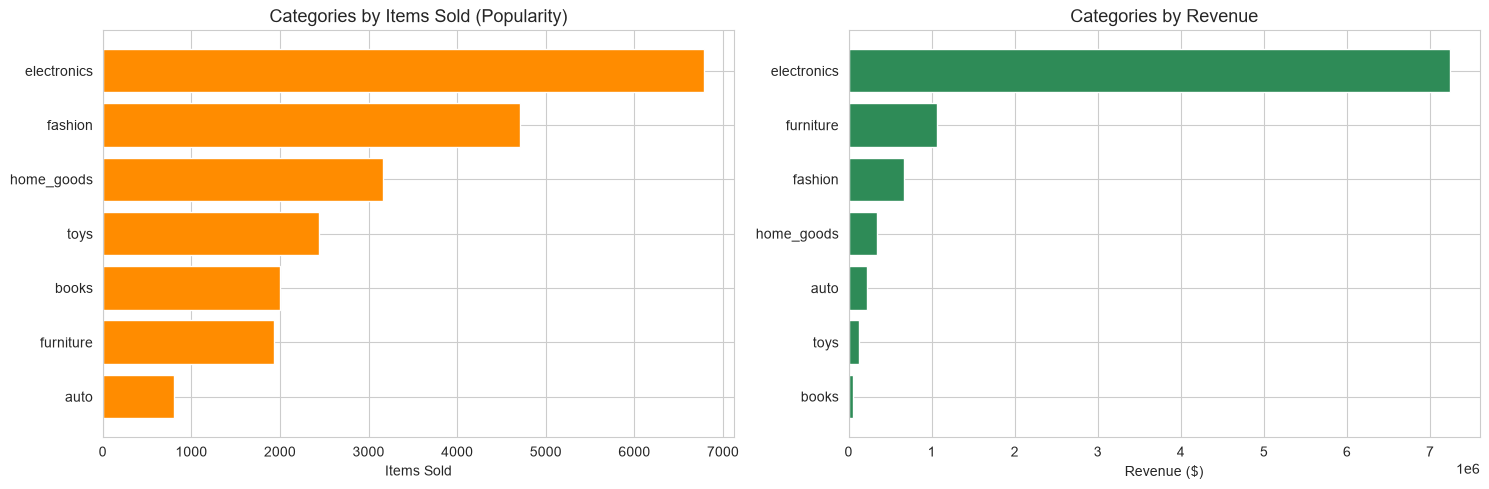

Top by volume: electronics | Top by revenue: electronics


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Category by items sold
cat_counts = items["product_category_name"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="darkorange")
axes[0].set_title("Categories by Items Sold (Popularity)")
axes[0].set_xlabel("Items Sold")

# Category by revenue
cat_revenue = items.groupby("product_category_name")["price"].sum().sort_values()
axes[1].barh(cat_revenue.index, cat_revenue.values, color="seagreen")
axes[1].set_title("Categories by Revenue")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\product_category.png", dpi=100, bbox_inches="tight")
plt.show()
print("Top by volume:", cat_counts.index[0], "| Top by revenue:", cat_revenue.index[-1])

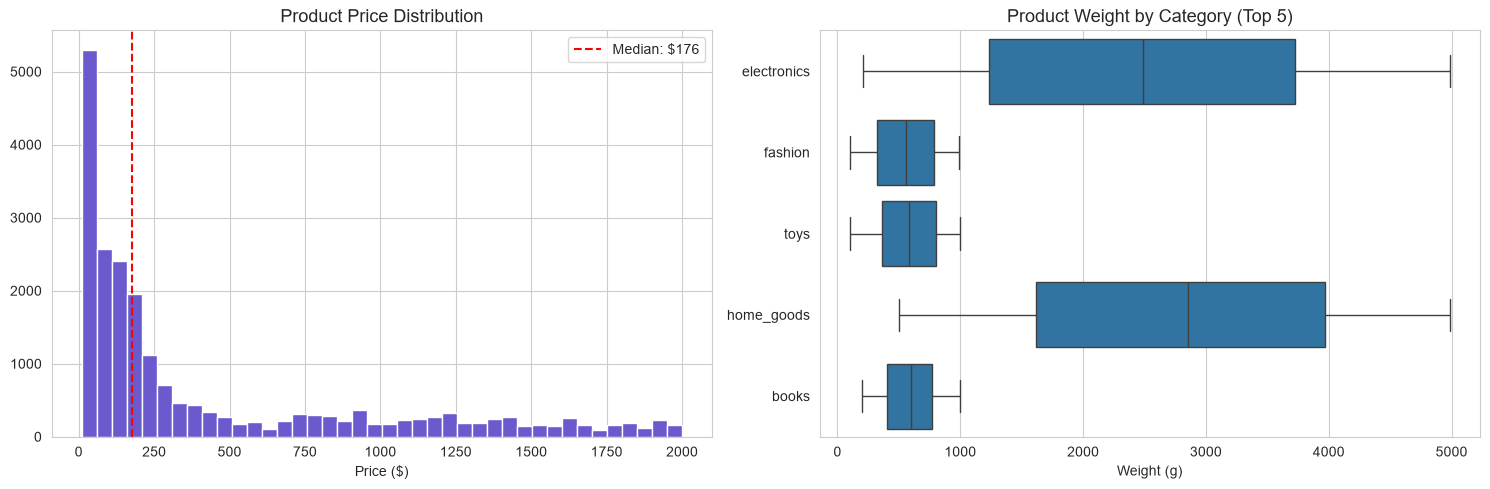

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Price distribution
axes[0].hist(items["price"], bins=40, color="slateblue", edgecolor="white")
axes[0].axvline(items["price"].median(), color="red", linestyle="--",
                label=f"Median: ${items['price'].median():.0f}")
axes[0].set_title("Product Price Distribution")
axes[0].set_xlabel("Price ($)"); axes[0].legend()

# Weight distribution by top categories
top_cats = items["product_category_name"].value_counts().head(5).index
items_top = items[items["product_category_name"].isin(top_cats)]
sns.boxplot(data=items_top, y="product_category_name", x="product_weight_g", ax=axes[1])
axes[1].set_title("Product Weight by Category (Top 5)")
axes[1].set_xlabel("Weight (g)"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\product_distribution.png", dpi=100, bbox_inches="tight")
plt.show()